In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [15]:
from google.colab import files
uploaded = files.upload()

df = pd.ExcelFile("HousePricePrediction.xlsx")
data = df.parse('Sheet1')

data.head()


Saving HousePricePrediction.xlsx to HousePricePrediction (1).xlsx


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [16]:
data = data.drop(columns=['Id'])

train_data = data[data['SalePrice'].notnull()].copy()
test_data = data[data['SalePrice'].isnull()].drop(columns=['SalePrice']).copy()

# Handle missing values in train data
for col in train_data.columns:
    if train_data[col].dtype == 'object':
        train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    else:
        train_data[col] = train_data[col].fillna(train_data[col].median())

# Handle missing values in test data
for col in test_data.columns:
    if test_data[col].dtype == 'object':
        test_data[col] = test_data[col].fillna(test_data[col].mode()[0])
    else:
        test_data[col] = test_data[col].fillna(test_data[col].median())

train_data_encoded = pd.get_dummies(train_data, drop_first=True)
test_data_encoded = pd.get_dummies(test_data, drop_first=True)

train_data_encoded, test_data_encoded = train_data_encoded.align(
    test_data_encoded, join="left", axis=1, fill_value=0
)


In [17]:
X = train_data_encoded.drop(columns=['SalePrice'])
y = train_data_encoded['SalePrice']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [19]:
y_pred = model.predict(X_valid)


===== Model Evaluation Results =====
RMSE: 54022.75
R² Score: 0.6195

===== Top 10 Influential Features =====
BldgType_Twnhs        -128761.191994
BldgType_2fmCon       -122587.069035
BldgType_TwnhsE       -108391.717847
BldgType_Duplex        -71952.516454
Exterior1st_Stone       57629.982298
Exterior1st_AsphShn     49898.036565
Exterior1st_BrkFace     38424.765970
MSZoning_RH             31238.594576
MSZoning_FV             28051.159919
MSZoning_RL             26812.215243
dtype: float64


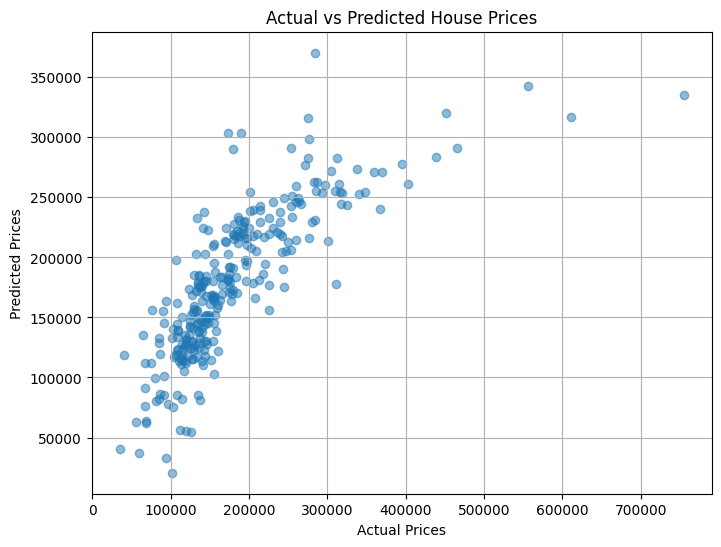

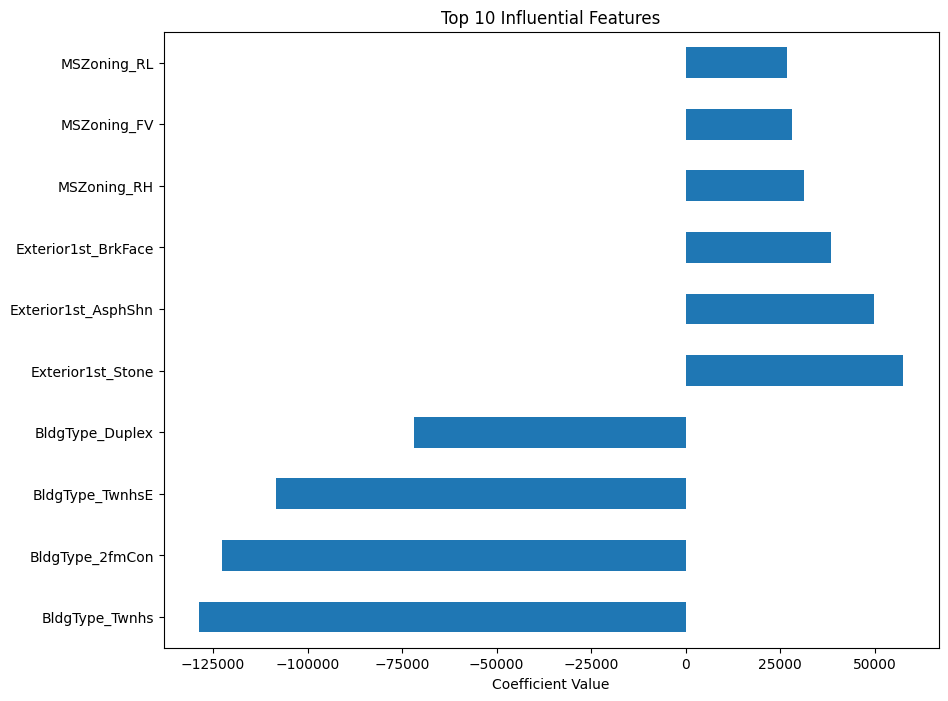

In [20]:
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

coefficients = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)


plt.figure(figsize=(8,6))
plt.scatter(y_valid, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)


plt.figure(figsize=(10,8))
coefficients.head(10).plot(kind='barh')
plt.xlabel("Coefficient Value")
plt.title("Top 10 Influential Features")


print("===== Model Evaluation Results =====")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print("\n===== Top 10 Influential Features =====")
print(coefficients.head(10))

plt.show()
